In [1]:
import geopandas as gpd

In [6]:
shp_file = "/Users/elqajjammohammed/Desktop/Extra-Work/PoCs/SatRing-One-Embedding-to-Bind-Them-all/data/raw/LNDCVR2023/Land Cover 2023.shp"

gdf = gpd.read_file(shp_file)
gdf.head(10)

/opt/anaconda3/envs/torch-env/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Polygon' is converted to 'Polygon Z'
  return ogr_read(


,class,province,district,shape_leng,area_ha,st_area_sh,st_length_,geometry
0,Cropland,Western,Nyamasheke,2.522712e+02,0.004380,4.379986e+01,2.522712e+02,"POLYGON Z ((395945.778 4720188.418 0, 395946.2..."
1,Forest,Western,Nyamasheke,2.522712e+02,0.004380,4.379986e+01,2.522712e+02,"POLYGON Z ((395945.778 4720188.418 0, 395946.2..."
2,Bareland,Southern,Huye,1.033394e+03,0.768043,7.680433e+03,1.033394e+03,"MULTIPOLYGON Z (((477712.183 4727742.451 0, 47..."
3,Built_Up_Area,Southern,Nyaruguru,5.375990e+06,7947.334411,7.947334e+07,5.375990e+06,"MULTIPOLYGON Z (((436319.308 4701099.489 0, 43..."
4,Waterbody,Southern,Nyaruguru,1.167685e+05,114.827903,1.148279e+06,1.167685e+05,"MULTIPOLYGON Z (((445642.786 4708433.334 0, 44..."
5,Wetland,Southern,Nyaruguru,3.789018e+04,0.165892,1.658916e+03,3.789018e+04,"MULTIPOLYGON Z (((450346.107 4703548.972 0, 45..."
6,Cropland,Southern,Huye,8.013410e+01,0.001811,1.810875e+01,8.013410e+01,"POLYGON Z ((457536.991 4717662.851 0, 457514.1..."
7,Forest,Southern,Huye,8.013410e+01,0.001811,1.810875e+01,8.013410e+01,"POLYGON Z ((457536.991 4717662.851 0, 457514.1..."
8,Cropland,Southern,Gisagara,3.834759e+02,0.784393,7.843935e+03,3.834759e+02,"POLYGON Z ((470872.665 4692474.059 0, 470868.6..."
9,Cropland,Southern,Nyamagabe,7.076449e+01,0.003176,3.176037e+01,7.076448e+01,"MULTIPOLYGON Z (((438834.558 4713801.692 0, 43..."


In [4]:
gdf.dtypes

class           object
province        object
district        object
shape_leng     float64
area_ha        float64
st_area_sh     float64
st_length_     float64
geometry      geometry
dtype: object

In [5]:
gdf.columns

Index(['class', 'province', 'district', 'shape_leng', 'area_ha', 'st_area_sh',
       'st_length_', 'geometry'],
      dtype='object')

In [7]:
# Global class wights
import numpy as np

classes_area = gdf.groupby("class")["area_ha"].sum()
total_area = np.sum(classes_area.values)
wights = (1 / np.sqrt(classes_area + 1e-6))

In [14]:
weights2 = classes_area / total_area    

In [16]:
weights2.sum()

np.float64(1.0000000000000002)

In [8]:
wights

class
Bareland                   0.038523
Built_Up_Area              0.001786
Cropland                   0.000915
Forest                     0.001300
Grassland_and_Shrubland    0.003221
Waterbody                  0.002568
Wetland                    0.002356
Name: area_ha, dtype: float64

In [9]:
max_weight = np.max(wights)

In [11]:
max_weight

np.float64(0.038523045118589866)

In [10]:
normalized_weights = wights / max_weight
normalized_weights

class
Bareland                   1.000000
Built_Up_Area              0.046358
Cropland                   0.023745
Forest                     0.033737
Grassland_and_Shrubland    0.083624
Waterbody                  0.066654
Wetland                    0.061166
Name: area_ha, dtype: float64

In [12]:
weight_lookup = normalized_weights.to_dict()

In [13]:
print(weight_lookup)

{'Bareland': 1.0, 'Built_Up_Area': 0.04635844941552911, 'Cropland': 0.02374472428710487, 'Forest': 0.033737329998378196, 'Grassland_and_Shrubland': 0.08362446271247463, 'Waterbody': 0.06665381180643647, 'Wetland': 0.06116630744599156}


In [26]:
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.mask import mask
from scipy.stats import entropy as shannon_entropy
import numpy as np

In [27]:
unique_classes = gdf['class'].unique()
CLASS_MAP_STR_TO_INT = {name: i + 1 for i, name in enumerate(unique_classes)}
CLASS_MAP_INT_TO_STR = {i + 1: name for i, name in enumerate(unique_classes)}

In [28]:
gdf['class_int'] = gdf['class'].map(CLASS_MAP_STR_TO_INT)
CLASS_COLUMN = 'class_int'

In [29]:
class_areas = gdf.groupby(CLASS_COLUMN)['area_ha'].sum()
weights = (1.0 / np.sqrt(class_areas + 1e-6))
max_weight = weights.max()
weight_lookup_int = (weights / max_weight).to_dict()

In [30]:
weight_lookup_int

{1: 0.02374472428710487,
 2: 0.033737329998378196,
 3: 1.0,
 4: 0.04635844941552911,
 5: 0.06665381180643647,
 6: 0.06116630744599156,
 7: 0.08362446271247463}

In [36]:
import os


def generate_importance_map(tile_id, tile_geom, gdf_full, weight_map_int, patch_size=224, target_res=10):
    gdf_clipped = gpd.clip(gdf_full, tile_geom)
    min_x, min_y, max_x, max_y = tile_geom.bounds

    height = int(np.ceil((max_y - min_y) / target_res))
    width = int(np.ceil((max_x - min_x) / target_res))
    transform = rasterio.transform.from_bounds(min_x, min_y, max_x, max_y, width, height)
    shapes = ((geom, value) for geom, value in zip(gdf_clipped.geometry, gdf_clipped[CLASS_COLUMN]))
    lulc_array = rasterize(
        shapes, 
        out_shape=(height, width), 
        transform=transform, 
        fill=0,
        dtype=rasterio.uint8
    )
    importance_band = np.zeros((height, width), dtype=np.float32)
    entropy_band = np.zeros((height, width), dtype=np.float32)
    
    for y in range(0, height - patch_size + 1, patch_size):
        for x in range(0, width - patch_size + 1, patch_size):
            patch_labels = lulc_array[y:y+patch_size, x:x+patch_size]
            valid_labels = patch_labels[patch_labels != 0]

            if len(valid_labels) < (patch_size * patch_size) * 0.95: 
                continue 

            counts = np.bincount(valid_labels.flatten())
            dominant_class_code = np.argmax(counts)

            non_zero_counts = counts[counts > 0]
            probs = non_zero_counts / non_zero_counts.sum()
            entropy = shannon_entropy(probs, base=2) 
            
            sampling_weight = weight_map_int.get(dominant_class_code, 0)
            
            importance_band[y:y+patch_size, x:x+patch_size] = sampling_weight
            entropy_band[y:y+patch_size, x:x+patch_size] = entropy

    output_profile = {
        'driver': 'GTiff', 'dtype': rasterio.float32, 
        'nodata': 0.0, 'width': width, 'height': height, 
        'count': 2, 'crs': gdf_clipped.crs, 'transform': transform
    }
    out_folder = "/Users/elqajjammohammed/Desktop/Extra-Work/PoCs/SatRing-One-Embedding-to-Bind-Them-all/importance_maps"
    os.makedirs(out_folder, exist_ok=True)
    output_filename = out_folder +f"/importance_map_{tile_id}.tif"
    with rasterio.open(output_filename, 'w', **output_profile) as dst:
        dst.write(importance_band, 1)
        dst.write(entropy_band, 2)
    
    print(f"Generated Importance Map for Tile: {tile_id}")

In [37]:

gdf_tiles = gpd.read_file("/Users/elqajjammohammed/Desktop/Extra-Work/PoCs/SatRing-One-Embedding-to-Bind-Them-all/sentinel2_tiling_grid.geojson")

for index, row in gdf_tiles.iterrows():
    
    tile_id = row['Name'] 
    if tile_id not in ["35MPT","35MQU","35MQT","35MQS","35MRU","35MRT","35MRS","36MTD","36MTC"]:
        continue
    tile_geom = row.geometry
    generate_importance_map(
        tile_id, 
        tile_geom, 
        gdf, 
        weight_lookup_int
    )

Generated Importance Map for Tile: 35MPT
Generated Importance Map for Tile: 35MQS
Generated Importance Map for Tile: 35MQT
Generated Importance Map for Tile: 35MQU
Generated Importance Map for Tile: 35MRS
Generated Importance Map for Tile: 35MRT
Generated Importance Map for Tile: 35MRU
Generated Importance Map for Tile: 36MTC
Generated Importance Map for Tile: 36MTD


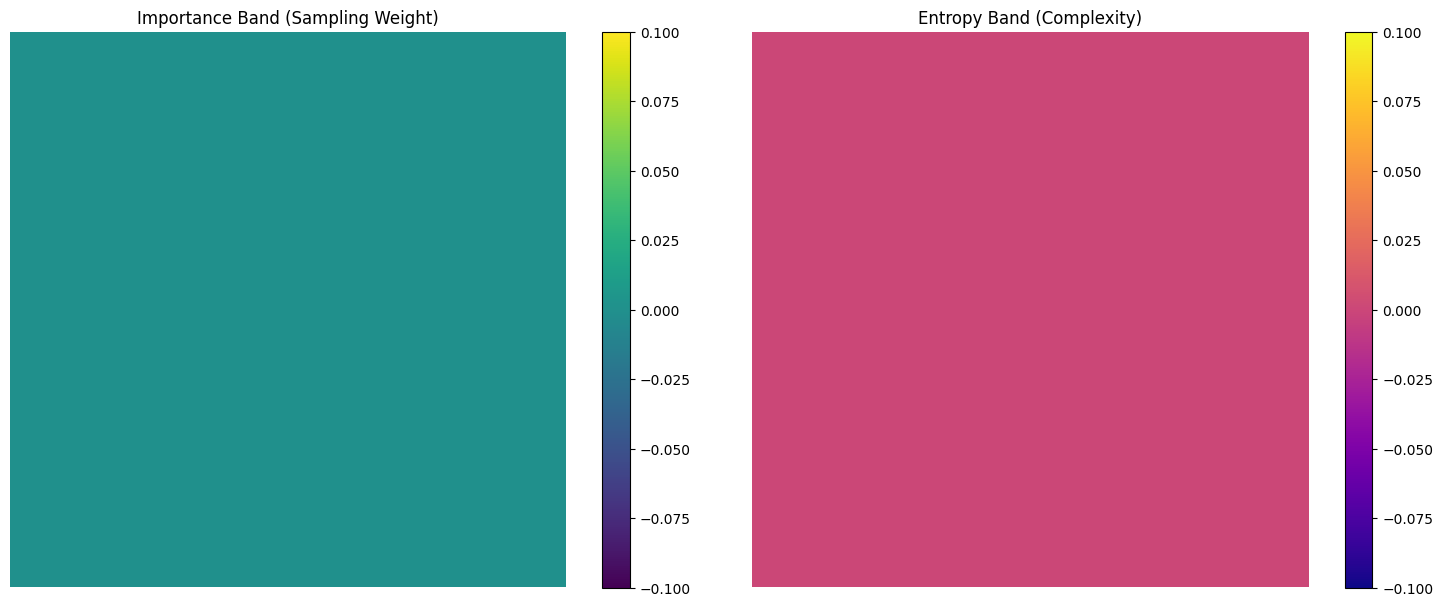

Unique importance values: [0.]
Entropy range: [0.000, 0.000]


In [38]:
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

with rasterio.open('/Users/elqajjammohammed/Desktop/Extra-Work/PoCs/SatRing-One-Embedding-to-Bind-Them-all/importance_maps/importance_map_35MQT.tif') as src:
    importance_band = src.read(1)
    entropy_band = src.read(2)
    transform = src.transform
    crs = src.crs

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

im1 = axes[0].imshow(importance_band, cmap='viridis')
axes[0].set_title('Importance Band (Sampling Weight)')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(entropy_band, cmap='plasma')
axes[1].set_title('Entropy Band (Complexity)')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

print(f"Unique importance values: {np.unique(importance_band)}")
print(f"Entropy range: [{entropy_band.min():.3f}, {entropy_band.max():.3f}]")

In [39]:
entropy_band.shape

(1, 1)